Objective: Using Python, Pandas, Numpy and SciKitLearn, and the diabetes dataset, 

- train a Machine Learning classification model that accurately classifies whether a patient is Diabetic or not.
- Use the following ML models: KNN, Random Forest and Support Vector machine (SVM).
  
  Build each of the models:
  1. use cross validation and
  2. without cross validation
  3. compare the models' performance.
     
Use the following evaluation approaches in each case: 
1. Accuracy
2. Classification report
3. Confusion matrix on a heatmap.
4. Please explain the results in details.

# Diabetes Classification Project

## Objective

The goal of this project is to build and evaluate multiple Machine Learning classification models to accurately predict whether a patient is Diabetic (1) or Non-Diabetic (0) using clinical and physiological features.

- The models used are: K-Nearest Neighbors (KNN), Random Forest, and Support Vector Machine (SVM).

- Each model will be trained: Without cross-validation and With cross-validation.

- Performance will be evaluated using Accuracy, Classification Report, and Confusion Matrix (heatmap).


## Dataset

The dataset contains patient medical measurements such as glucose level, blood pressure, BMI, insulin level, age, and diabetes pedigree function. The target variable is Diabetic (0 or 1).

## Project Structure

The notebook is organized as follows:
Data Loading → Exploratory Analysis → Preprocessing → Model Training (without CV) → Evaluation → Model Training (with CV) → Performance Comparison → Conclusion.

In [1]:
# Data Manipulation Libraries
import pandas as pd          # For data handling and DataFrame operations
import numpy as np           # For numerical computations

# Data Visualization Libraries
import matplotlib.pyplot as plt   # For plotting graphs
import seaborn as sns             # For advanced statistical visualizations

# Scikit-Learn Utilities
from sklearn.model_selection import train_test_split, cross_val_score  # Data splitting & cross-validation
from sklearn.preprocessing import StandardScaler                       # Feature scaling

# Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier        # KNN model
from sklearn.ensemble import RandomForestClassifier       # Random Forest model
from sklearn.svm import SVC                               # Support Vector Machine

# Model Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load Dataset

df = pd.read_csv(r"C:\Users\HP\Downloads\ML & NN\diabetes dataset.csv")   # Replace with correct file path if needed

# Display first 5 rows
df.head()

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0


In [3]:
# Statistical Summary

df.describe()

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
count,1.000000e+04,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.502122e+06,3.25580,107.850200,71.207500,28.81760,139.243600,31.567022,0.400944,30.134100,0.334400
std,2.892868e+05,3.40572,31.920909,16.801478,14.50648,133.777919,9.804366,0.381463,12.106047,0.471804
min,1.000038e+06,0.00000,44.000000,24.000000,7.00000,14.000000,18.200807,0.078044,21.000000,0.000000
25%,1.251672e+06,0.00000,84.000000,58.000000,15.00000,39.000000,21.247427,0.137065,22.000000,0.000000
50%,1.504394e+06,2.00000,105.000000,72.000000,31.00000,85.000000,31.922421,0.199698,24.000000,0.000000
75%,1.754608e+06,6.00000,129.000000,85.000000,41.00000,197.000000,39.328921,0.621158,35.000000,1.000000
max,1.999997e+06,14.00000,192.000000,117.000000,92.00000,796.000000,56.034628,2.301594,77.000000,1.000000


In [4]:
df.isnull().sum()

PatientID                 0
Pregnancies               0
PlasmaGlucose             0
DiastolicBloodPressure    0
TricepsThickness          0
SerumInsulin              0
BMI                       0
DiabetesPedigree          0
Age                       0
Diabetic                  0
dtype: int64

In [5]:
print(df.shape)
print(df.info())

(10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               10000 non-null  int64  
 1   Pregnancies             10000 non-null  int64  
 2   PlasmaGlucose           10000 non-null  int64  
 3   DiastolicBloodPressure  10000 non-null  int64  
 4   TricepsThickness        10000 non-null  int64  
 5   SerumInsulin            10000 non-null  int64  
 6   BMI                     10000 non-null  float64
 7   DiabetesPedigree        10000 non-null  float64
 8   Age                     10000 non-null  int64  
 9   Diabetic                10000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 781.4 KB
None


In [6]:
print(df["Diabetic"].value_counts())

Diabetic
0    6656
1    3344
Name: count, dtype: int64


### Data Summary 

The dataset contains 10,000 observations with 9 predictive features and 1 binary target variable (Diabetic).

There are no missing values and no medically impossible entries (e.g., zero glucose or BMI). Feature ranges appear realistic, although some high values (e.g., insulin levels) may indicate potential outliers but remain clinically plausible.

The target variable shows moderate class imbalance (~33% diabetic, ~67% non-diabetic), which is acceptable for classification modeling.

Overall, the dataset appears clean and suitable for preprocessing and model development.

In [7]:
# Feature Selection

# Drop PatientID (not useful for prediction)
df = df.drop(columns=["PatientID"])

# Separate features and target
X = df.drop("Diabetic", axis=1)
y = df["Diabetic"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (10000, 8)
Target vector shape: (10000,)


In [8]:
# Train-Test Split

# Split data into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling

scaler = StandardScaler()

# Fit scaler on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check shapes
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 8)
X_test shape: (2000, 8)
y_train shape: (8000,)
y_test shape: (2000,)


## Modeling Without Cross-Validation

In this section, we train and evaluate machine learning models without cross-validation to get an initial performance baseline.

### KNN Without Cross-Validation

In [9]:
# K-Nearest Neighbors (KNN) Model
# Without Cross-Validation

# Initialize KNN with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

# Make predictions on test set
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate performance
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.864

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90      1331
           1       0.83      0.74      0.78       669

    accuracy                           0.86      2000
   macro avg       0.86      0.83      0.84      2000
weighted avg       0.86      0.86      0.86      2000



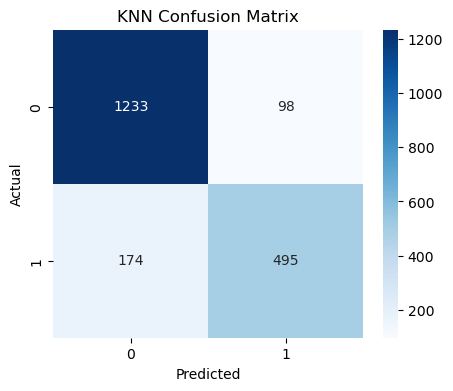

In [10]:
# KNN Confusion Matrix Heatmap

# Compute confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### KNN Performance (Without Cross-Validation)

**Accuracy:** 86.4%

**Precision / Recall / F1-score:**
- Non-Diabetic (0): Precision 0.88 | Recall 0.93 | F1 0.90
- Diabetic (1): Precision 0.83 | Recall 0.74 | F1 0.78

**Confusion Matrix:** 

|            | Predicted 0 | Predicted 1 |
|------------|-------------|-------------|
| Actual 0   | 1233        | 98          |
| Actual 1   | 174         | 495         | 

> **Observation:** 
> - Most non-diabetics are correctly predicted (TN = 1233), but 98 were incorrectly predicted as diabetic (FP).  
> - 174 diabetics were missed (FN), while 495 were correctly identified (TP).  
> - Overall, the model performs well for non-diabetics but may miss some diabetic cases, which is critical in medical diagnosis.

### Random Forest Without Cross-Validation

In [11]:
# Random Forest Classifier
# Without Cross-Validation

# Initialize Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)  # No scaling needed for Random Forest

# Make predictions
y_pred_rf = rf.predict(X_test)

# Evaluate performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.938

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      1331
           1       0.92      0.89      0.91       669

    accuracy                           0.94      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.94      0.94      0.94      2000



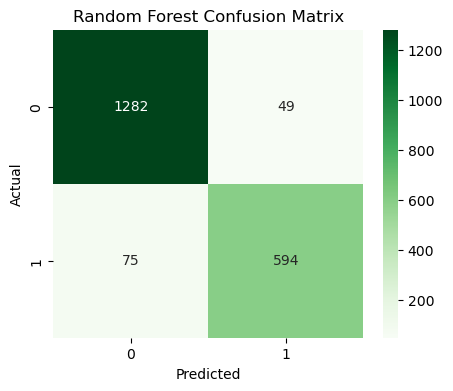

In [12]:
# Random Forest Confusion Matrix

# Compute confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest Performance (Without Cross-Validation)

**Accuracy:** 93.8%

**Precision / Recall / F1-score:**
- Non-Diabetic (0): Precision 0.94 | Recall 0.96 | F1 0.95
- Diabetic (1): Precision 0.92 | Recall 0.89 | F1 0.91

**Confusion Matrix:**

|            | Predicted 0 | Predicted 1 |
|------------|-------------|-------------|
| Actual 0   | 1282 (TN)   | 49 (FP)     |
| Actual 1   | 75 (FN)     | 594 (TP)    |

> **Observation:** Random Forest predicts both classesery well. It **misses wer diabetics** than KNN (FN = 75 vs 174), making it more suitable for medical diagnosis.

In [13]:
# Support Vector Machine (SVM)
# Without Cross-Validation

# Initialize SVM with RBF kernel
svm = SVC(kernel='rbf', random_state=42)

# Train the model
svm.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test_scaled)

# Evaluate performance
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8785

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91      1331
           1       0.84      0.79      0.81       669

    accuracy                           0.88      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.88      0.88      0.88      2000



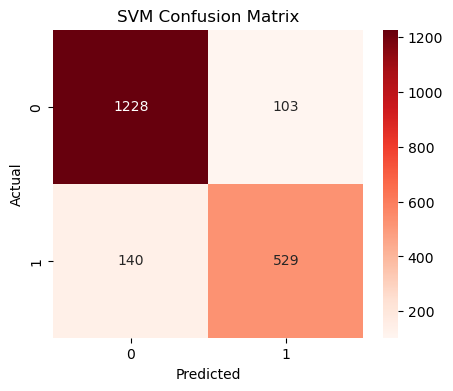

In [14]:
# SVM Confusion Matrix

# Compute confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SVM Performance (Without Cross-Validation)

**Accuracy:** 87.85%

**Precision / Recall / F1-score:**
- Non-Diabetic (0): Precision 0.90 | Recall 0.92 | F1 0.91
- Diabetic (1): Precision 0.84 | Recall 0.79 | F1 0.81

**Confusion Matrix:**

|            | Predicted 0 | Predicted 1 |
|------------|-------------|-------------|
| Actual 0   | 1228 (TN)   | 103 (FP)    |
| Actual 1   | 140 (FN)    | 529 (TP)    |

> **Observation:** SVM performs we overall but **misses moreiabetic cases** (FN = 140) than Random Fo est (FN = 75). Random Forest is therefore more reliable for medical diagnosis.

## Model Comparison (Without Cross-Validation)

| Model          | Accuracy | Diabetic Recall | False Negatives (FN) |
|----------------|---------|----------------|--------------------|
| KNN            | 86.4%   | 0.74           | 174                |
| Random Forest  | 93.8%   | 0.89           | 75                 |
| SVM            | 87.85%  | 0.79           | 140                |

> **Observation:** Random Forest outperforms KNN and SVM in both overall accuracy and correctly identifying diabetics (highest recall, lowest FN), making it the preferred model in this context.

## Models with Cross Validation

In [15]:
# Initialize KNN
knn_cv = KNeighborsClassifier(n_neighbors=5)

# Perform 5-fold cross-validation on the entire dataset
cv_scores_knn = cross_val_score(knn_cv, StandardScaler().fit_transform(X), y, cv=5)

# Display results
print("KNN Cross-Validation Scores:", cv_scores_knn)
print("Mean CV Accuracy:", cv_scores_knn.mean())

KNN Cross-Validation Scores: [0.87   0.87   0.8565 0.8525 0.873 ]
Mean CV Accuracy: 0.8644000000000001


KNN CV Accuracy: 0.863
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      5325
           1       0.82      0.76      0.79      2675

    accuracy                           0.86      8000
   macro avg       0.85      0.84      0.84      8000
weighted avg       0.86      0.86      0.86      8000



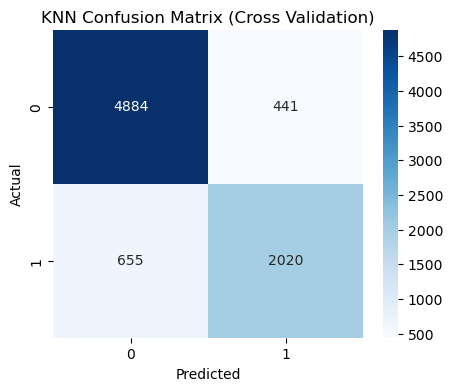

In [16]:
from sklearn.model_selection import cross_val_predict

# Generate predictions using cross validation
y_pred_knn_cv = cross_val_predict(knn, X_train_scaled, y_train, cv=5)

# Accuracy
print("KNN CV Accuracy:", accuracy_score(y_train, y_pred_knn_cv))

# Classification report
print(classification_report(y_train, y_pred_knn_cv))

# Confusion matrix
cm_knn_cv = confusion_matrix(y_train, y_pred_knn_cv)

# Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn_cv, annot=True, fmt='d', cmap='Blues')
plt.title("KNN Confusion Matrix (Cross Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
# Initialize Random Forest
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

# Perform 5-fold cross-validation (no scaling needed)
cv_scores_rf = cross_val_score(rf_cv, X, y, cv=5)

# Display results
print("Random Forest CV Scores:", cv_scores_rf)
print("Mean CV Accuracy:", cv_scores_rf.mean())

Random Forest CV Scores: [0.9405 0.9355 0.9355 0.935  0.931 ]
Mean CV Accuracy: 0.9355


Random Forest CV Accuracy: 0.93275

Random Forest Classification Report (CV):

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5325
           1       0.91      0.88      0.90      2675

    accuracy                           0.93      8000
   macro avg       0.93      0.92      0.92      8000
weighted avg       0.93      0.93      0.93      8000



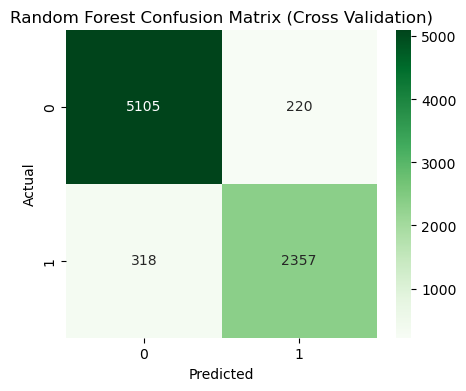

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Generate cross-validation predictions
y_pred_rf_cv = cross_val_predict(rf_cv, X_train, y_train, cv=5)

# Accuracy
print("Random Forest CV Accuracy:", accuracy_score(y_train, y_pred_rf_cv))

# Classification report
print("\nRandom Forest Classification Report (CV):\n")
print(classification_report(y_train, y_pred_rf_cv))

# Confusion matrix
cm_rf_cv = confusion_matrix(y_train, y_pred_rf_cv)

# Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_cv, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix (Cross Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Initialize SVM
svm_cv = SVC(kernel='rbf')

# Perform 5-fold cross-validation with scaled features
cv_scores_svm = cross_val_score(svm_cv, StandardScaler().fit_transform(X), y, cv=5)

# Display results
print("SVM CV Scores:", cv_scores_svm)
print("Mean CV Accuracy:", cv_scores_svm.mean())

SVM CV Scores: [0.8865 0.881  0.879  0.879  0.8915]
Mean CV Accuracy: 0.8834


SVM CV Accuracy: 0.879125

SVM Classification Report (CV):

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      5325
           1       0.84      0.79      0.81      2675

    accuracy                           0.88      8000
   macro avg       0.87      0.86      0.86      8000
weighted avg       0.88      0.88      0.88      8000



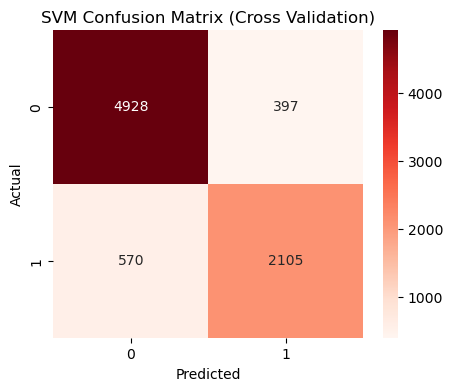

In [20]:
# Generate cross-validation predictions
y_pred_svm_cv = cross_val_predict(svm_cv, X_train_scaled, y_train, cv=5)

# Accuracy
print("SVM CV Accuracy:", accuracy_score(y_train, y_pred_svm_cv))

# Classification report
print("\nSVM Classification Report (CV):\n")
print(classification_report(y_train, y_pred_svm_cv))

# Confusion matrix
cm_svm_cv = confusion_matrix(y_train, y_pred_svm_cv)

# Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm_cv, annot=True, fmt='d', cmap='Reds')
plt.title("SVM Confusion Matrix (Cross Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Comparison (With Cross-Validation)

| Model         | Mean CV Accuracy | Accuracy   | Precision (Diabetic) | Recall (Diabetic) | F1 Score (Diabetic) |
| ------------- | ---------------- | ---------- | -------------------- | ----------------- | ------------------- |
| KNN           | 86.44%           | 86.3%      | 0.82                 | 0.76              | 0.79                |
| Random Forest | **93.55%**       | **93.27%** | **0.91**             | **0.88**          | **0.90**            |
| SVM           | 88.34%           | 87.91%     | 0.84                 | 0.79              | 0.81                |

> **Observation:** Random Forest achieves the highest performance across all metrics, including accuracy, recall, and F1-score for diabetic patients. This confirms that Random Forest is the most robust and reliable model for predicting diabetes in this dataset.


# Final Model Comparison

| Model          | Accuracy (No CV) | Diabetic Recall (No CV) | FN (No CV) | Mean CV Accuracy | Notes |
|----------------|-----------------|------------------------|------------|----------------|-------|
| KNN            | 86.4%           | 0.74                   | 174        | 86.44%         | Sensitive to scaling; misses more diabetics |
| Random Forest  | 93.8%           | 0.89                   | 75         | 93.55%         | Best performance; lowest FN; stable |
| SVM            | 87.85%          | 0.79                   | 140        | 88.34%         | Stable with scaling; better than KNN but below RF |

> **Observation:** Random Forest consistently outperforms KNN and SVM, both in overall accuracy and diabetic recall. It minimizes false negatives, which is crucial for early detection of diabetes. The cross-validation confirms model robustness and reliability.

> - Dataset moderately imbalanced (33% diabetic). Random Forest handles imbalance well; KNN and SVM slightly underperform for diabetics.

# Summary of Solution and Process

## 1. Problem Understanding
The objective of this project was to predict whether a patient is **Diabetic (1)** or **Non-Diabetic (0)** based on clinical features like glucose level, blood pressure, BMI, insulin, and age. Accurate prediction is critical for early intervention and patient care.

## 2. Data Understanding and Preparation
- The dataset contained 10,000 patient records with 9 predictive features and 1 target.  
- **Data inspection** revealed no missing values and feature ranges were medically plausible.  
- The target variable is moderately imbalanced (~33% diabetic), requiring careful evaluation of **recall** for the diabetic class.  
- PatientID was removed as it does not carry predictive information.  
- Features were scaled using StandardScaler for models sensitive to magnitude (KNN, SVM).  
- The dataset was split into 80% training and 20% testing.

## 3. Modeling Approach
We implemented three classification models:

1. K-Nearest Neighbors (KNN)
2. Random Forest
3. Support Vector Machine (SVM)

Each model was evaluated without cross-validation first, then we applied a 5-fold cross-validation to assess generalization performance and reduce variability due to a single train-test split.

### Key Observations from Without Cross-Validation:
- **KNN:** Accuracy 86.4%, diabetic recall 0.74, FN = 174.  Performs well for non-diabetics but misses a significant number of diabetics.  
- **Random Forest:** Accuracy 93.8%, diabetic recall 0.89, FN = 75. Strong overall performance and better identification of diabetics.  
- **SVM:** Accuracy 87.85%, diabetic recall 0.79, FN = 140.  Better than KNN but still misses more diabetics than Random Forest.

### Cross-Validation Results:
- **KNN:** Mean CV Accuracy = 86.44%  
- **Random Forest:** Mean CV Accuracy = 93.55%  
- **SVM:** Mean CV Accuracy = 88.34%  
- CV results are consistent with single split, indicating the dataset is large and representative.  

## 4. Interpretation and Insights
- **Random Forest** consistently outperforms KNN and SVM, both in overall accuracy and diabetic recall, making it the preferred model in this medical context.  
- **KNN** is sensitive to feature scaling and has higher false negatives for diabetics.  
- **SVM** is stable with scaling, but recall for diabetics is lower than Random Forest.  
- Confusion matrices highlight that correctly predicting diabetics (reducing FN) is critical — Random Forest achieves the lowest FN (75) compared to KNN (174) and SVM (140).  

## 5. Conclusion
- **Solution:** Random Forest is the best choice for this diabetes classification task.  
- **Process Highlights:**  
  - Followed CRISP-DM methodology (understanding, preparation, modeling, evaluation).  
  - Checked data quality, feature plausibility, and class balance.  
  - Applied both single train-test evaluation and robust 5-fold cross-validation.  
  - Evaluated using multiple metrics (accuracy, recall, precision, F1, confusion matrix).  
- **Meaning:** Using Random Forest reduces missed diabetic cases, improving early detection and patient care decisions.  

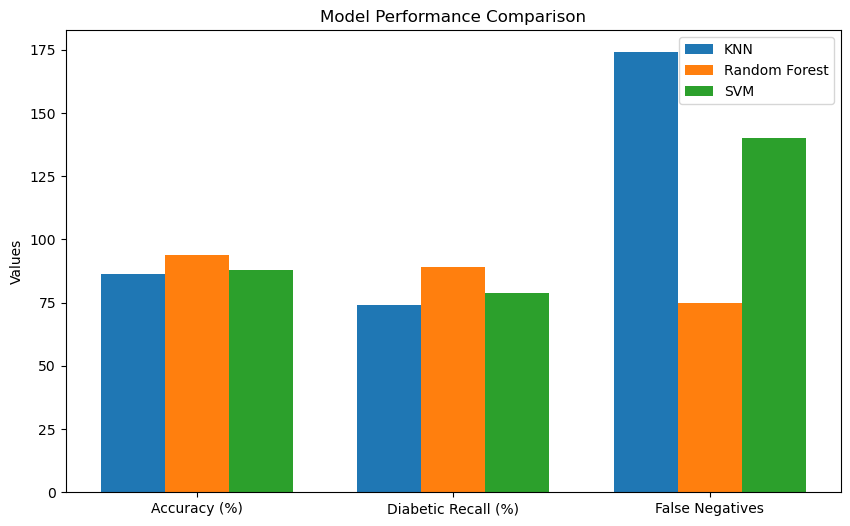

In [24]:
# Metrics
metrics = ['Accuracy (%)', 'Diabetic Recall (%)', 'False Negatives']
models = ['KNN', 'Random Forest', 'SVM']

# Values for each model
values = np.array([
    [86.4, 74, 174],      # KNN
    [93.8, 89, 75],       # Random Forest
    [87.85, 79, 140]      # SVM
])

x = np.arange(len(metrics))  # label locations
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(10,6))

# Plot bars for each model
for i, model in enumerate(models):
    ax.bar(x + i*width - width, values[i], width, label=model)

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Values')
ax.set_title('Model Performance Comparison')
ax.legend()
plt.show()